# Import Library

In [2]:
#File processing
import csv
import os
import zipfile

#Model building
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, BatchNormalization, Dense, Dropout, Embedding, LSTM, MultiHeadAttention, LayerNormalization, add
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import plot_model, to_categorical
from sklearn.model_selection import train_test_split

#Data Vizualization Tool
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

#Other
from collections import Counter #Count number of element(s) from list
import gc #garbage collector
from nltk.translate.bleu_score import corpus_bleu #Evaluate n-gram score
import numpy as np #Array usage
import re #Filter string from a given pattern
from tqdm import tqdm_notebook #Progress bar
import warnings #Handle warnings

mixed_precision.set_global_policy("mixed_float16") #For better memory efficincy and computation speed since float16 is smaller than float32
warnings.filterwarnings('ignore') #Ignore all warning

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Laptop GPU, compute capability 8.9


# Read Dataset

In [4]:
#Zip, Image and captions path
images_directory = './Data/IC30K/flickr30k_images/flickr30k_images/'
captions_path = 'flickr30k_images/results.csv'
zip_path = './Data/IC30K.zip'

#Read image filename and its caption pair directly from zip file
def load_captions(zip_path, csv_filename):
    captions = []
    with zipfile.ZipFile(zip_path, 'r') as z:
        with z.open(csv_filename) as f:
            reader = csv.DictReader(
                (line.decode('utf-8') for line in f), delimiter='|'
            )
            reader.fieldnames = [name.strip() for name in reader.fieldnames]
            for row in reader:
                img = row.get('image_name')
                caption = row.get('comment')
                if caption:
                    captions.append(f"{img},{caption.strip().lower()}")
    return captions

captions = load_captions(zip_path, captions_path)
captions[:15:3]

['1000092795.jpg,two young guys with shaggy hair look at their hands while hanging out in the yard .',
 '1000092795.jpg,a man in a blue shirt standing in a garden .',
 '10002456.jpg,workers look down from up above on a piece of equipment .',
 '10002456.jpg,three men on a large rig .',
 '1000268201.jpg,a little girl climbing the stairs to her playhouse .']

# Preprocess Dataset

## Image:

In [7]:
# Define augmentation pipeline
image_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.3)
])

def preprocess_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = np.expand_dims(img, axis=0)

    # Apply augmentation
    img = image_augmentation(img)

    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img

inception_v3_model = InceptionV3(weights = 'imagenet', input_shape=(299, 299, 3))
inception_v3_model.layers.pop()
inception_v3_model = Model(inputs=inception_v3_model.inputs, outputs=inception_v3_model.layers[-2].output)

## Caption:

In [11]:
def clean_text(text):
    # Lowercase
    lowercase = tf.strings.lower(text)
    # Characters to strip (punctuation + digits)
    strip_chars = "!\"#$%&'()*+,-./:;=?@[\]^_`{|}~1234567890"
    # Regex replace
    cleaned = tf.strings.regex_replace(lowercase, "[%s]" % re.escape(strip_chars), "")
    # Convert back to Python string
    return cleaned.numpy().decode("utf-8").strip()

cleaned_captions = [clean_text(caption.split(',')[1]) for caption in captions]
cleaned_captions[:15:2]

['two young guys with shaggy hair look at their hands while hanging out in the yard',
 'two men in green shirts are standing in a yard',
 'two friends enjoy time spent together',
 'workers look down from up above on a piece of equipment',
 'four men on top of a tall structure',
 'a child in a pink dress is climbing up a set of stairs in an entry way',
 'a little girl climbing the stairs to her playhouse',
 'a girl going into a wooden building']

In [12]:
# Define min and max caption length
MIN_LEN = 4
MAX_LEN = 24   # same as SEQ_LENGTH in Transformer

filtered_captions = []
filtered_ids = []

for i, caption in enumerate(cleaned_captions):
    tokens = caption.split()
    if MIN_LEN <= len(tokens) <= MAX_LEN:
        filtered_captions.append(caption)
        item = captions[i].split(',')[0] + '\t' + 'start ' + caption + ' end\n'
        filtered_ids.append(item)

# Replace old lists with filtered ones
cleaned_captions = filtered_captions
captions_IDs = filtered_ids

captions_IDs[:20:3], len(captions_IDs)

(['1000092795.jpg\tstart two young guys with shaggy hair look at their hands while hanging out in the yard end\n',
  '1000092795.jpg\tstart two friends enjoy time spent together end\n',
  '10002456.jpg\tstart two men working on a machine wearing hard hats end\n',
  '1000268201.jpg\tstart a child in a pink dress is climbing up a set of stairs in an entry way end\n',
  '1000268201.jpg\tstart a little girl climbing into a wooden playhouse end\n',
  '1000344755.jpg\tstart a man in a blue shirt is standing on a ladder cleaning a window end\n',
  '1000344755.jpg\tstart a man on a ladder cleans a window end\n'],
 153044)

## Exploratory Data Analysis (EDA):

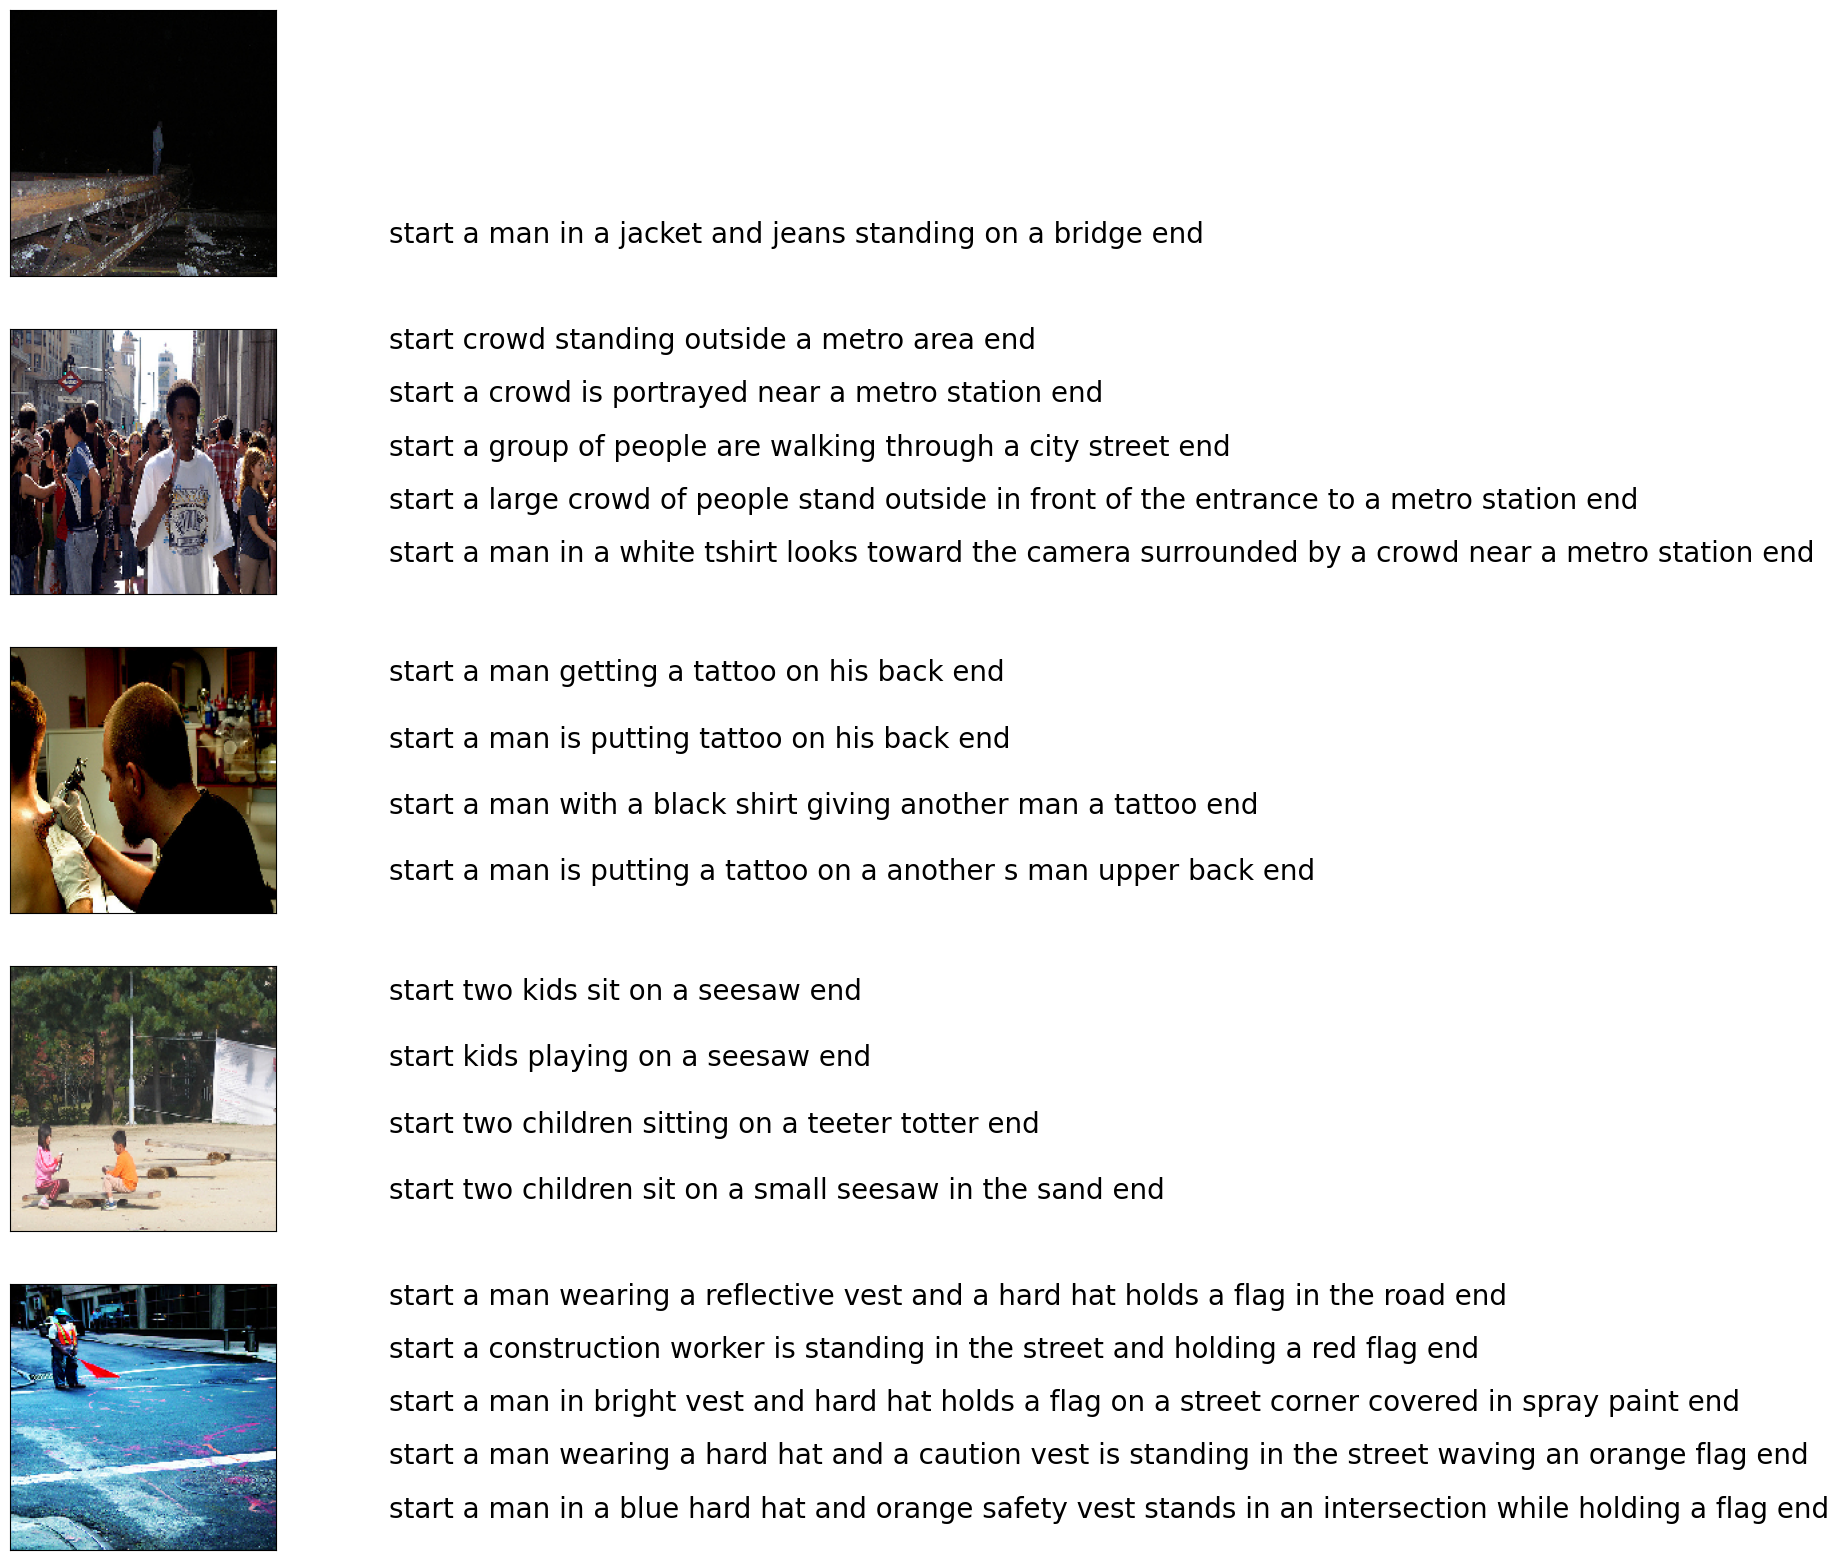

In [14]:
def visualaization(data, num_of_images):
    captions_dictionary = {}
    for item in data[100:100+(num_of_images)*5]:
        image_id, caption = item.split('\t')
        if image_id not in captions_dictionary:
            captions_dictionary[image_id] = []
        captions_dictionary[image_id].append(caption)

    count = 1
    fig = plt.figure(figsize=(10,20))
    for filename in list(captions_dictionary.keys())[:num_of_images]:
        captions = captions_dictionary[filename]
        image_load = load_img(images_directory+filename, target_size=(199,199,3))

        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(captions))
        for i, caption in enumerate(captions):
            ax.text(0,i,caption,fontsize=20)
        count += 1
    plt.show()

visualaization(captions_IDs, 5)

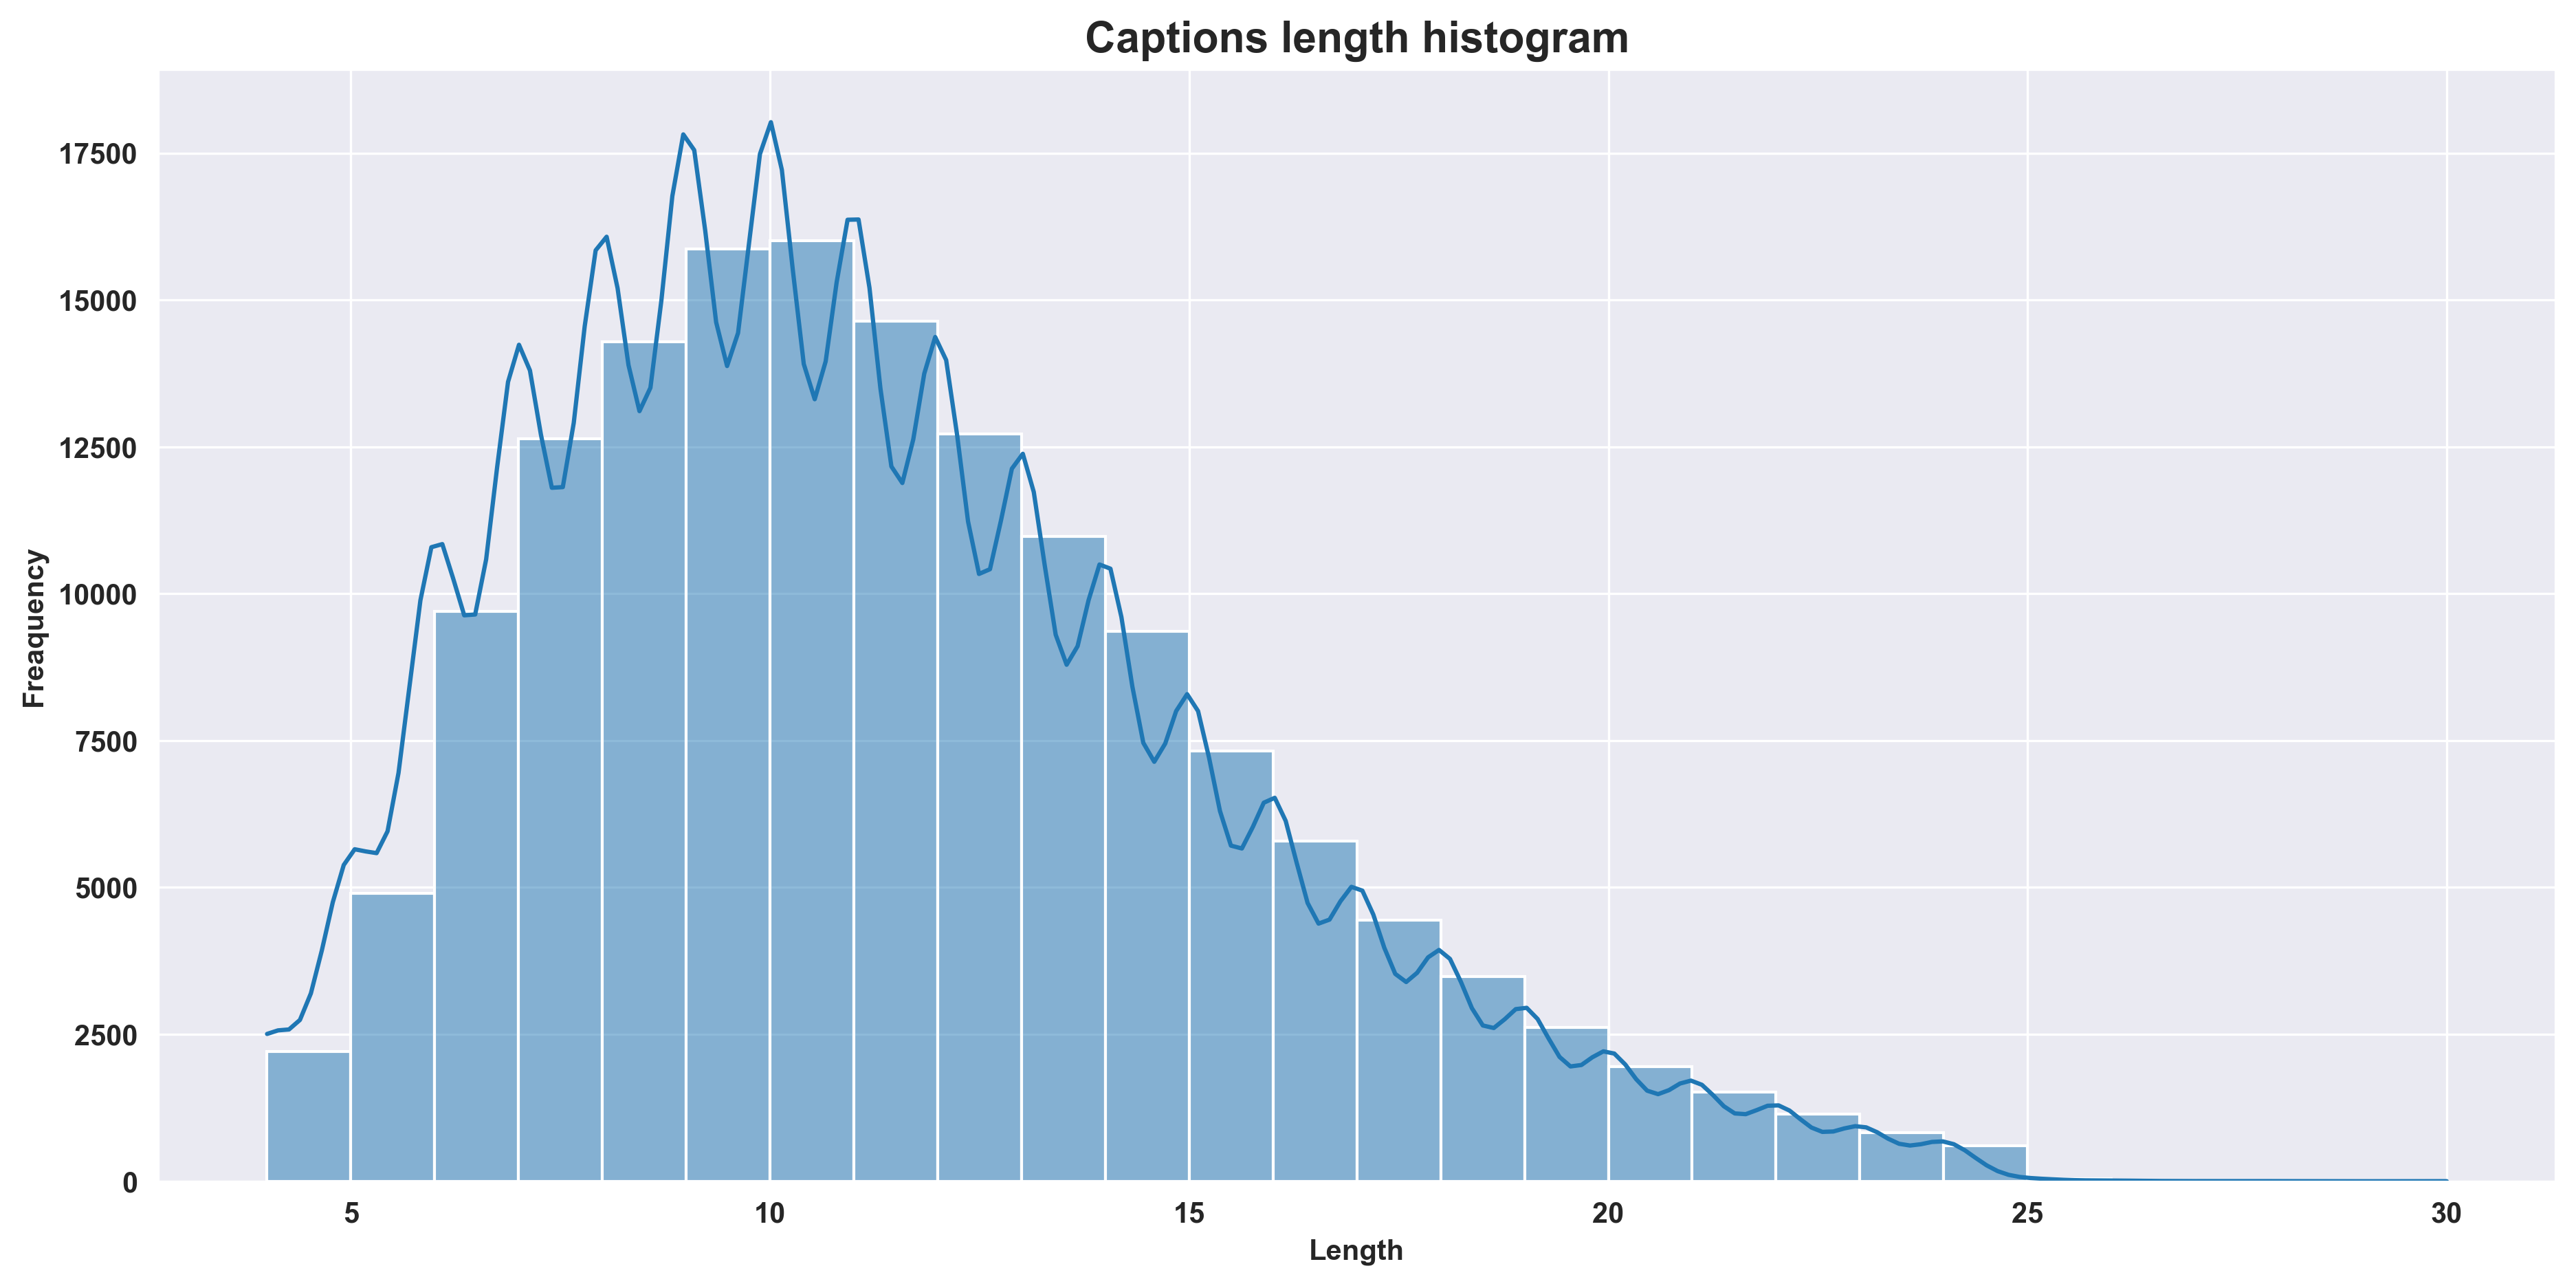

In [16]:
def captions_length(data):
    plt.figure(figsize=(15, 7), dpi=300)
    sns.set_style('darkgrid')
    sns.histplot(x=[len(x.split(' ')) for x in data], kde=True, binwidth=1)
    plt.title('Captions length histogram', fontsize=15, fontweight='bold')
    plt.xticks(fontweight='bold')
    plt.yticks(fontweight='bold')
    plt.xlabel('Length', fontweight='bold')
    plt.ylabel('Freaquency', fontweight='bold')
    plt.show()

captions_length(cleaned_captions)

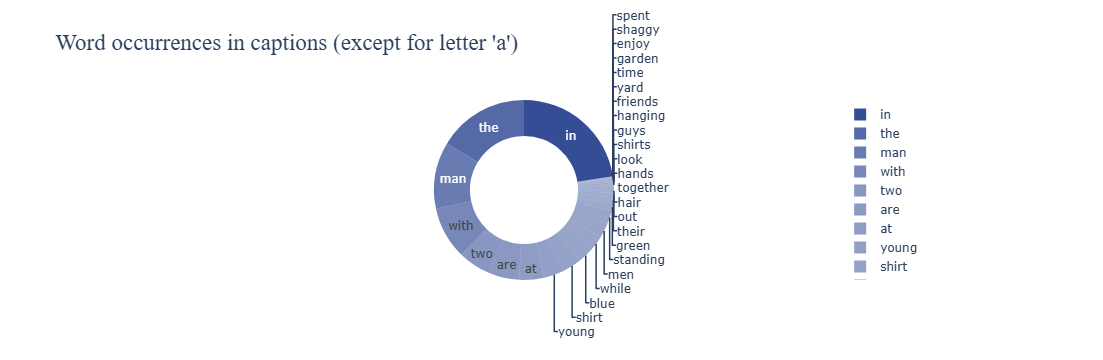

In [17]:
def word_occurrences(data):
    # Combining all sentences into a single string
    all_text = ' '.join(data)
    all_text = all_text.replace('a ', '')
    all_text = all_text.replace('start ', '')
    all_text = all_text.replace('end ', '')
    # Splitting the text into words and count occurrences
    word_counts = Counter(all_text.split())

    words = list(word_counts.keys())[:30]
    values = list(word_counts.values())[:30]

    # Normalize values to be between 0 and 1
    normalized_values = np.array(values) / np.max(values)
    colors = np.array(['rgba(30, 58, 138, {})'.format(0.4 + 0.5 * (value)) for value in normalized_values])

    fig = go.Figure(data=[go.Pie(labels=words, values=values, hole=.6, marker=dict(colors=colors), textinfo='label')])

    fig.update_layout(title_text='Word occurrences in captions (except for letter \'a\')', title_font=dict(size=23, family='Balto'))

    fig.show()
    
word_occurrences(cleaned_captions)

## Data Splitting:

In [19]:
all_image_ids = [
    f for f in os.listdir(images_directory)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

train_image_ids, val_image_ids = train_test_split(all_image_ids, test_size=0.15, random_state=42)
val_image_ids, test_image_ids = train_test_split(val_image_ids, test_size=0.1, random_state=42)

train_captions, val_captions, test_captions = [], [], []
for caption in captions_IDs:
    image_id, _ = caption.split('\t')

    if image_id in train_image_ids:
        train_captions.append(caption)

    elif image_id in val_image_ids:
        val_captions.append(caption)

    elif image_id in test_image_ids:
        test_captions.append(caption)

    else:
        print('Unknown image ID !')

train_captions[0], val_captions[0], test_captions[0], len(train_captions)/5, len(val_captions)/5, len(test_captions)/5

('1000092795.jpg\tstart two young guys with shaggy hair look at their hands while hanging out in the yard end\n',
 '1000919630.jpg\tstart a man sits in a chair while holding a large stuffed animal of a lion end\n',
 '1001465944.jpg\tstart an asian man wearing a black suit stands near a darkhaired woman and a brownhaired woman end\n',
 26022.4,
 4128.4,
 458.0)

## Feature Extraction:

In [21]:
BATCH_SIZE = 10000
train_image_features, val_image_features, test_image_features = {}, {}, {}  # A Dictionary to store image features with their corresponding IDs

def extract_image_features(model, image_path):
    img = preprocess_image(image_path)
    features = model.predict(img, verbose=0)
    return features
    
def process_batch(batch_ids, model, batch_index,train_image_features, val_image_features, test_image_features):
    for image_id in batch_ids:
        image_path = os.path.join(images_directory, image_id)
        image_features = extract_image_features(model, image_path)
        if image_id in train_image_ids:
            train_image_features[image_id] = image_features.flatten()  # Flattening the features
            pbar.update(1)

        elif image_id in val_image_ids:
            val_image_features[image_id] = image_features.flatten()  # Flattening the features
            pbar.update(1)

        elif image_id in test_image_ids:
            test_image_features[image_id] = image_features.flatten()  # Flattening the features
            pbar.update(1)

        else:
            print('Unknown image ID !')
    
    # Clear memory
    gc.collect()
    return train_image_features, val_image_features, test_image_features

pbar = tqdm_notebook(total=len(all_image_ids), position=0, leave=True, colour='green')

# Split all_image_ids into chunks of 10k
for i in range(0, len(all_image_ids), BATCH_SIZE):
    batch_ids = all_image_ids[i:i+BATCH_SIZE]
    train_image_features, val_image_features, test_image_features = process_batch(batch_ids, inception_v3_model, i//BATCH_SIZE, train_image_features, val_image_features, test_image_features)
print("Feature extraction-->")
print("Train: ",len(train_image_features))
print("Validate: ",len(val_image_features))
print("Test: ",len(test_image_features))

pbar.close()

  0%|          | 0/31783 [00:00<?, ?it/s]

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



Feature extraction-->
Train:  27015
Validate:  4291
Test:  477


In [36]:
#vocabulary size
def tokenize_captions(captions):
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(captions)
    return tokenizer
    
tokenizer = tokenize_captions(cleaned_captions)
vocab_size = len(tokenizer.word_index) + 1
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 18417


#  Model Developement

## Generator:

In [38]:
#Randomize data
def data_generator(captions, image_features, tokenizer, max_caption_length, batch_size):
    num_samples = len(captions)
    image_ids = list(image_features.keys())
    while True:
        np.random.shuffle(image_ids)  # Shuffle image_ids for each epoch
        for start_idx in range(0, num_samples, batch_size):
            end_idx = min(start_idx + batch_size, num_samples)
            X_images, X_captions, y = [], [], []
            for caption in captions[start_idx:end_idx]:
                image_id, caption_text = caption.split('\t')
                caption_text = caption_text.rstrip('\n')
                seq = tokenizer.texts_to_sequences([caption_text])[0] # Tokenizing the caption
                for i in range(1, len(seq)):
                    in_seq, out_seq = seq[:i], seq[i] # X_caption, Y
                    in_seq = pad_sequences([in_seq], maxlen=max_caption_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
                    X_images.append(image_features[image_id])
                    X_captions.append(in_seq)
                    y.append(out_seq)

            yield [np.array(X_images), np.array(X_captions)], np.array(y)


max_caption_length = max(len(caption.split()) for caption in cleaned_captions) + 1

cnn_output_dim = inception_v3_model.output_shape[1] # 2048

batch_size_train = 128 #270
batch_size_val = 64 #150

train_data_generator = data_generator(train_captions, train_image_features, tokenizer, max_caption_length, batch_size_train)
val_data_generator = data_generator(val_captions, val_image_features, tokenizer, max_caption_length, batch_size_val)

## Embedding:

In [40]:
# Unzip once (you can skip if already extracted)
zip_path = "./Data/glove.2024.wikigiga.300d.zip"
extract_dir = "./Data/"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

embedding_path = "./Data/wiki_giga_2024_300_MFT20_vectors_seed_2024_alpha_0.75_eta_0.05_combined.txt"

def load_embeddings(embedding_path, tokenizer, embedding_dim=300):
    vocab_size = len(tokenizer.word_index) + 1
    embedding_matrix = np.zeros((vocab_size, embedding_dim))

    # Only keep words in tokenizer
    with open(embedding_path, encoding="utf8") as f:
        for line in f:
            values = line.rstrip().split(" ")
            word = values[0]
            if word in tokenizer.word_index:
                idx = tokenizer.word_index[word]
                if idx < vocab_size:
                    embedding_matrix[idx] = np.asarray(values[1:], dtype="float32")
    return embedding_matrix

embedding_matrix = load_embeddings(embedding_path, tokenizer, embedding_dim=300)

## Build neuron network:

In [41]:
def build_model(vocab_size, max_caption_length, cnn_output_dim, embedding_matrix=None, embedding_dim=300):
    # Image feature branch
    base_model = efficientnet.EfficientNetB0(include_top=False, weights="imagenet", input_shape=(299,299,3))
    base_model.trainable = False
    input_image = Input(shape=(cnn_output_dim,), name='Features_Input')
    fe1 = BatchNormalization()(input_image)
    fe2 = Dense(256, activation='relu')(fe1)
    fe2 = Dropout(0.4)(fe2)
    fe3 = BatchNormalization()(fe2)

    # Caption sequence branch
    input_caption = Input(shape=(max_caption_length,), name='Sequence_Input')
    if embedding_matrix is not None:
        # Use pretrained Dolma/GloVe embeddings
        se1 = Embedding(vocab_size,
                        embedding_dim,
                        weights=[embedding_matrix],
                        input_length=max_caption_length,
                        trainable=True,#False
                        mask_zero=True)(input_caption)
    else:
        # Fallback: train embeddings from scratch
        se1 = Embedding(vocab_size, 256, mask_zero=True)(input_caption)

    # Stacked LSTMs for richer sequence modeling
    se2 = LSTM(256, return_sequences=True)(se1)
    attn_out = MultiHeadAttention(num_heads=4, key_dim=256)(se2, se2)
    se3 = LayerNormalization()(se2 + attn_out)
    se3 = LSTM(256)(se3)
    se3 = Dropout(0.4)(se3)

    # Decoder
    decoder1 = add([fe3, se3])
    decoder2 = Dense(256, activation='relu')(decoder1)
    decoder2 = Dropout(0.4)(decoder2)
    outputs = Dense(vocab_size, activation='softmax', name='Output_Layer')(decoder2)

    model = Model(inputs=[input_image, input_caption], outputs=outputs, name='Image_Captioning')
    return model

caption_model = build_model(vocab_size, max_caption_length, cnn_output_dim, embedding_matrix=embedding_matrix, embedding_dim=300)

class WarmupLearningRate(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, target_lr=1e-4, warmup_steps=1000):
        super().__init__()
        self.target_lr = target_lr
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        # Linear warmup
        warmup_lr = self.target_lr * (step / warmup_steps)
        return tf.cond(step < warmup_steps,
                       lambda: warmup_lr,
                       lambda: self.target_lr)

lr_schedule = WarmupLearningRate(target_lr=1e-4, warmup_steps=2000)
optimizer = Adam(learning_rate=lr_schedule, clipnorm=1.0)
caption_model.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), optimizer=optimizer)#'categorical_crossentropy'

caption_model.summary()

Model: "Image_Captioning"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Sequence_Input (InputLayer)    [(None, 25)]         0           []                               
                                                                                                  
 embedding (Embedding)          (None, 25, 300)      5525100     ['Sequence_Input[0][0]']         
                                                                                                  
 lstm (LSTM)                    (None, 25, 256)      570368      ['embedding[0][0]']              
                                                                                                  
 Features_Input (InputLayer)    [(None, 2048)]       0           []                               
                                                                                   

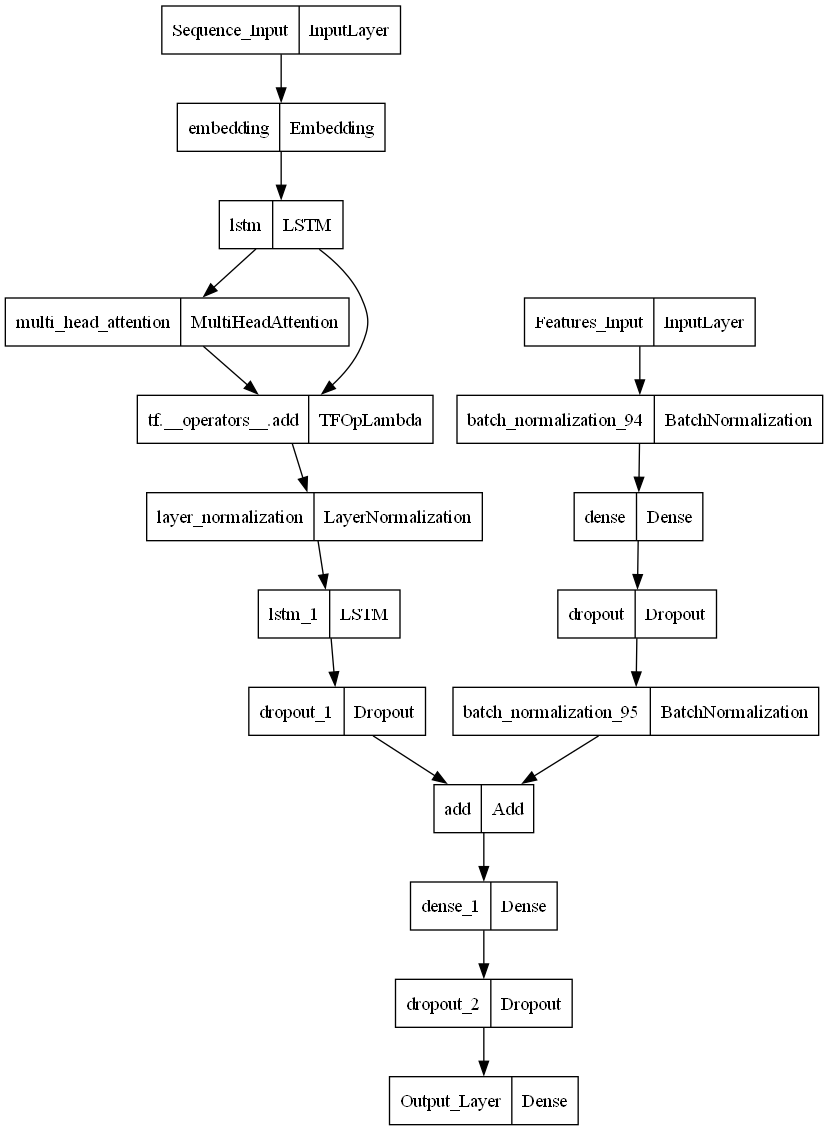

In [42]:
plot_model(caption_model)

## Training:

In [43]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = caption_model.fit(train_data_generator, steps_per_epoch=len(train_captions) // batch_size_train,
                        validation_data=val_data_generator, validation_steps=len(val_captions) // batch_size_val,
                        epochs=100, callbacks=[early_stopping])

Epoch 1/100
1016/1016 [==============================] - 519s 500ms/step - loss: 7.3335 - val_loss: 5.7958
Epoch 2/100
1016/1016 [==============================] - 503s 495ms/step - loss: 5.2698 - val_loss: 4.6614
Epoch 3/100
1016/1016 [==============================] - 493s 485ms/step - loss: 4.5872 - val_loss: 4.3105
Epoch 4/100
1016/1016 [==============================] - 488s 480ms/step - loss: 4.3550 - val_loss: 4.1453
Epoch 5/100
1016/1016 [==============================] - 490s 482ms/step - loss: 4.2170 - val_loss: 4.0370
Epoch 6/100
1016/1016 [==============================] - 489s 482ms/step - loss: 4.1178 - val_loss: 3.9562
Epoch 7/100
1016/1016 [==============================] - 488s 480ms/step - loss: 4.0431 - val_loss: 3.9005
Epoch 8/100
1016/1016 [==============================] - 489s 481ms/step - loss: 3.9838 - val_loss: 3.8583
Epoch 9/100
1016/1016 [==============================] - 484s 476ms/step - loss: 3.9351 - val_loss: 3.8177
Epoch 10/100
1016/1016 [=============

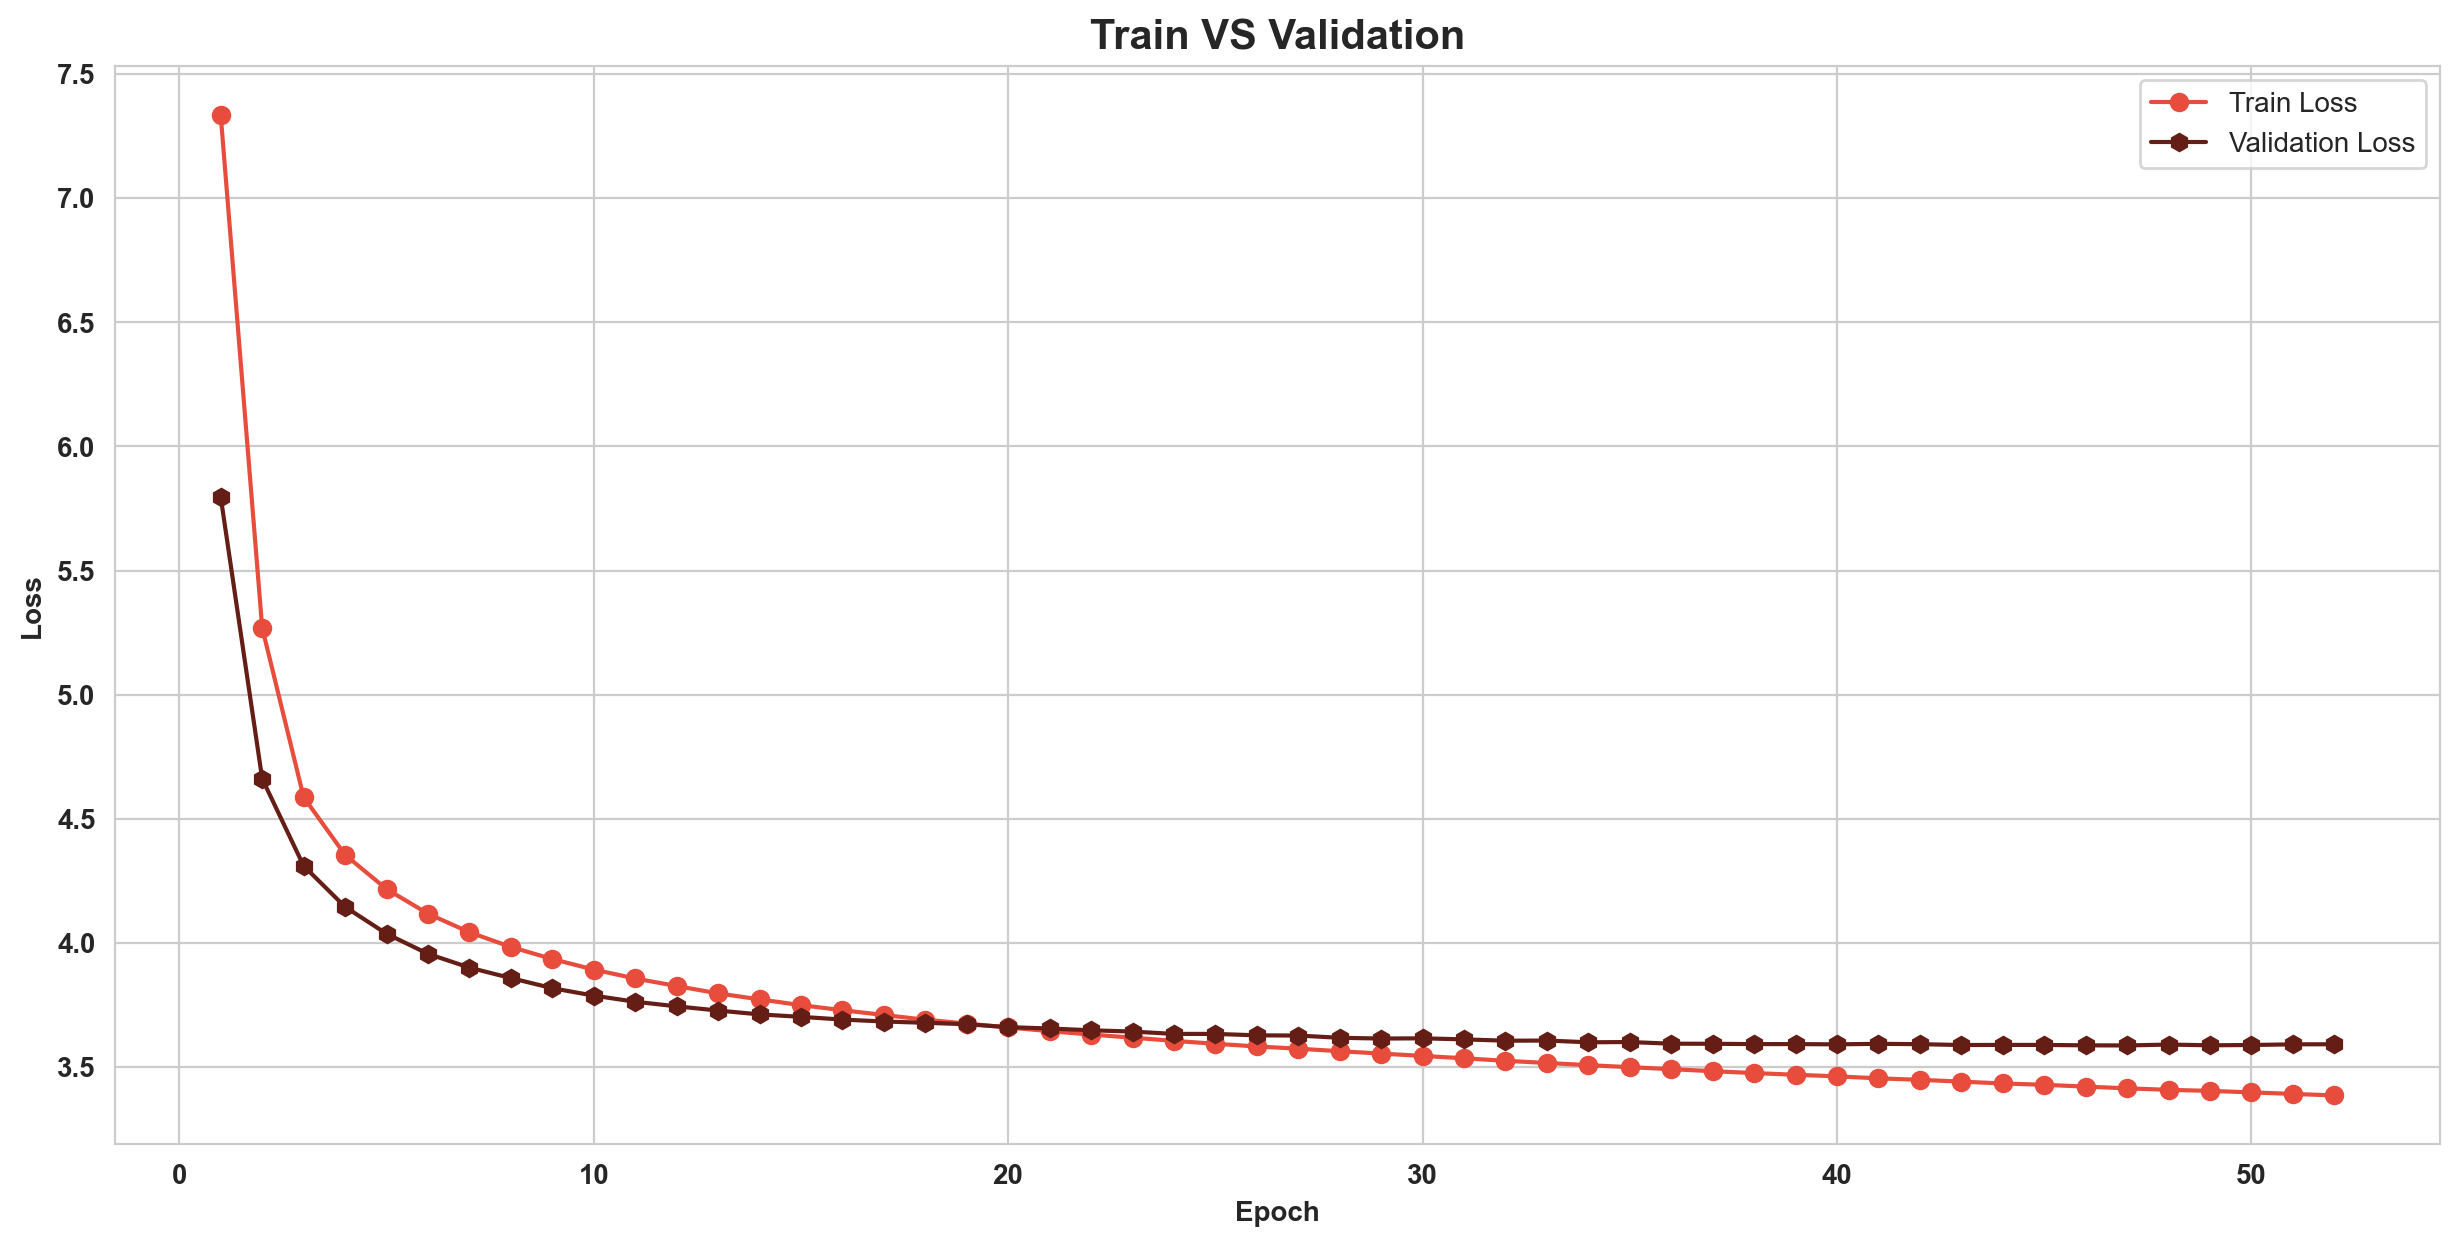

In [44]:
plt.figure(figsize=(15, 7), dpi=200)
sns.set_style('whitegrid')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['loss'], color='#E74C3C', marker='o')
plt.plot([x+1 for x in range(len(history.history['loss']))], history.history['val_loss'], color='#641E16', marker='h')
plt.title('Train VS Validation', fontsize=15, fontweight='bold')
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.legend(['Train Loss', 'Validation Loss'], loc='best')
plt.show()

## Model  Evalaution:

In [48]:
def greedy_generator(image_features):
    in_text = 'start '
    for _ in range(max_caption_length):
        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_caption_length).reshape((1,max_caption_length))
        prediction = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
        idx = np.argmax(prediction)
        word = tokenizer.index_word[idx]
        in_text += ' ' + word
        if word == 'end':
            break

    in_text = in_text.replace('start ', '')
    in_text = in_text.replace(' end', '')

    return in_text

In [49]:
def beam_search_generator(image_features, K_beams = 3, log = False):
    start = [tokenizer.word_index['start']]
    start_word = [[start, 0.0]]
    for _ in range(max_caption_length):
        temp = []
        for s in start_word:
            sequence  = pad_sequences([s[0]], maxlen=max_caption_length).reshape((1,max_caption_length))
            preds = caption_model.predict([image_features.reshape(1,cnn_output_dim), sequence], verbose=0)
            word_preds = np.argsort(preds[0])[-K_beams:]
            for w in word_preds:
                next_cap, prob = s[0][:], s[1]
                next_cap.append(w)
                if log:
                    prob += np.log(preds[0][w]) # assign a probability to each K words
                else:
                    prob += preds[0][w]
                temp.append([next_cap, prob])
                
        start_word = temp
        start_word = sorted(start_word, reverse=False, key=lambda l: l[1])
        start_word = start_word[-K_beams:]

    start_word = start_word[-1][0]
    captions_ = [tokenizer.index_word[i] for i in start_word]
    final_caption = []
    for i in captions_:
        if i != 'end':
            final_caption.append(i)
        else:
            break
        
    final_caption = ' '.join(final_caption[1:])
    return final_caption

In [50]:
def BLEU_score(actual, greedy, beam_search):
    score_greedy_1 = corpus_bleu(actual, greedy, weights=(1, 0, 0, 0)) 
    score_greedy_2 = corpus_bleu(actual, greedy, weights=(0.5, 0.5, 0, 0)) 
    score_BS_1 = corpus_bleu(actual, beam_search, weights=(1, 0, 0, 0)) 
    score_BS_2 = corpus_bleu(actual, beam_search, weights=(0.5, 0.5, 0, 0)) 
    
    return [
        (f'BLEU-2 Greedy: {round(score_BS_2, 5)}'),
        (f'BLEU-1 Greedy: {round(score_BS_1, 5)}'),
        (f'Greedy: {greedy[0]}'),
        (f'BLEU-2 Beam Search: {round(score_greedy_2, 5)}'),
        (f'BLEU-1 Beam Search: {round(score_greedy_1, 5)}'),
        (f'Beam Search:  {beam_search[0]}')
    ]

In [51]:
generated_captions = {}

pbar = tqdm_notebook(total=len(test_image_features), position=0, leave=True, colour='green')
for image_id in test_image_features:
    cap = greedy_generator(test_image_features[image_id])
    generated_captions[image_id] = cap
    pbar.update(1)

pbar.close()

  0%|          | 0/477 [00:00<?, ?it/s]

In [52]:
test_actual_captions = {}
for line in test_captions:
    filename, caption = line.split("\t", 1)
    caption = caption.strip()

    test_actual_captions[filename] = caption

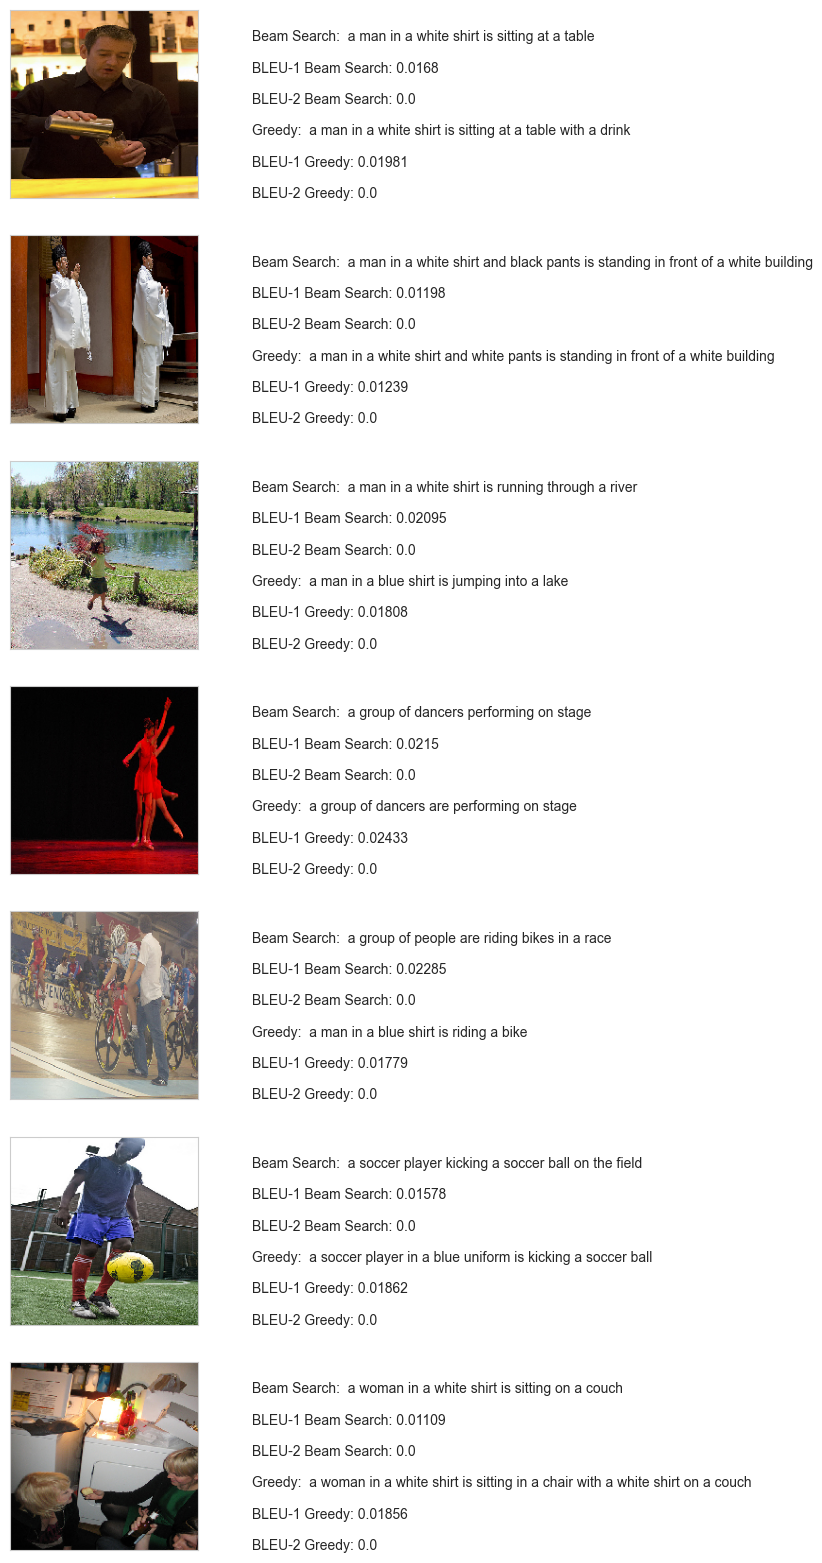

In [53]:
def visualization(data, greedy_caps, beamS_generator, evaluator, num_of_images):
    keys = list(data.keys()) 
    images = [np.random.choice(keys) for i in range(num_of_images)] # Randomly selected images
    count = 1
    fig = plt.figure(figsize=(6,20))
    for filename in images:
        actual_cap = data[filename]
        actual_cap = [x.replace("start ", "") for x in actual_cap]
        actual_cap = [x.replace(" end", "") for x in actual_cap]

        greedy_cap = greedy_caps[filename]
        beamS_cap = beamS_generator(test_image_features[filename])

        caps_with_score = evaluator(actual_cap, [greedy_cap]*(len(actual_cap)), [beamS_cap]*(len(actual_cap)))

        image_load = load_img(images_directory+filename, target_size=(199,199,3))
        ax = fig.add_subplot(num_of_images,2,count,xticks=[],yticks=[])
        ax.imshow(image_load)
        count += 1

        ax = fig.add_subplot(num_of_images,2,count)
        plt.axis('off')
        ax.plot()
        ax.set_xlim(0,1)
        ax.set_ylim(0,len(caps_with_score))
        for i, text in enumerate(caps_with_score):
            ax.text(0,i,text,fontsize=10)
        count += 1
    plt.show()

visualization(test_actual_captions, generated_captions, beam_search_generator, BLEU_score, 7)